In [6]:
# import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
# Load dataset
df = pd.read_csv('hospital_readmissions.csv')
df

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,[80-90),14,77,1,30,0,0,0,Missing,Circulatory,Other,Circulatory,no,normal,no,no,yes
24996,[80-90),2,66,0,24,0,0,0,Missing,Digestive,Injury,Other,no,high,yes,yes,yes
24997,[70-80),5,12,0,6,0,1,0,Missing,Other,Other,Other,normal,no,no,no,yes
24998,[70-80),2,61,3,15,0,0,0,Family/GeneralPractice,Respiratory,Diabetes,Other,no,no,yes,yes,no


In [8]:

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [9]:
# dataset Overview
df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

(25000, 17)

In [10]:
# missing values

df.isnull().sum()

,0
age,0
time_in_hospital,0
n_lab_procedures,0
n_procedures,0
n_medications,0
n_outpatient,0
n_inpatient,0
n_emergency,0
medical_specialty,0
diag_1,0


In [11]:
# percentage
(df.isnull().sum()/len(df))*100

,0
age,0.0
time_in_hospital,0.0
n_lab_procedures,0.0
n_procedures,0.0
n_medications,0.0
n_outpatient,0.0
n_inpatient,0.0
n_emergency,0.0
medical_specialty,0.0
diag_1,0.0


In [12]:
# check target values

df['readmitted'].value_counts()

,count
readmitted,
no,13246
yes,11754


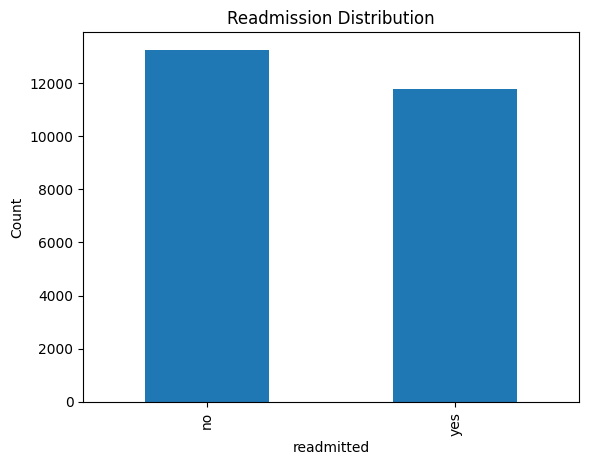

In [13]:
# Visualization

df['readmitted'].value_counts().plot(
    kind='bar'
)

plt.title("Readmission Distribution")
plt.ylabel("Count")
plt.show()

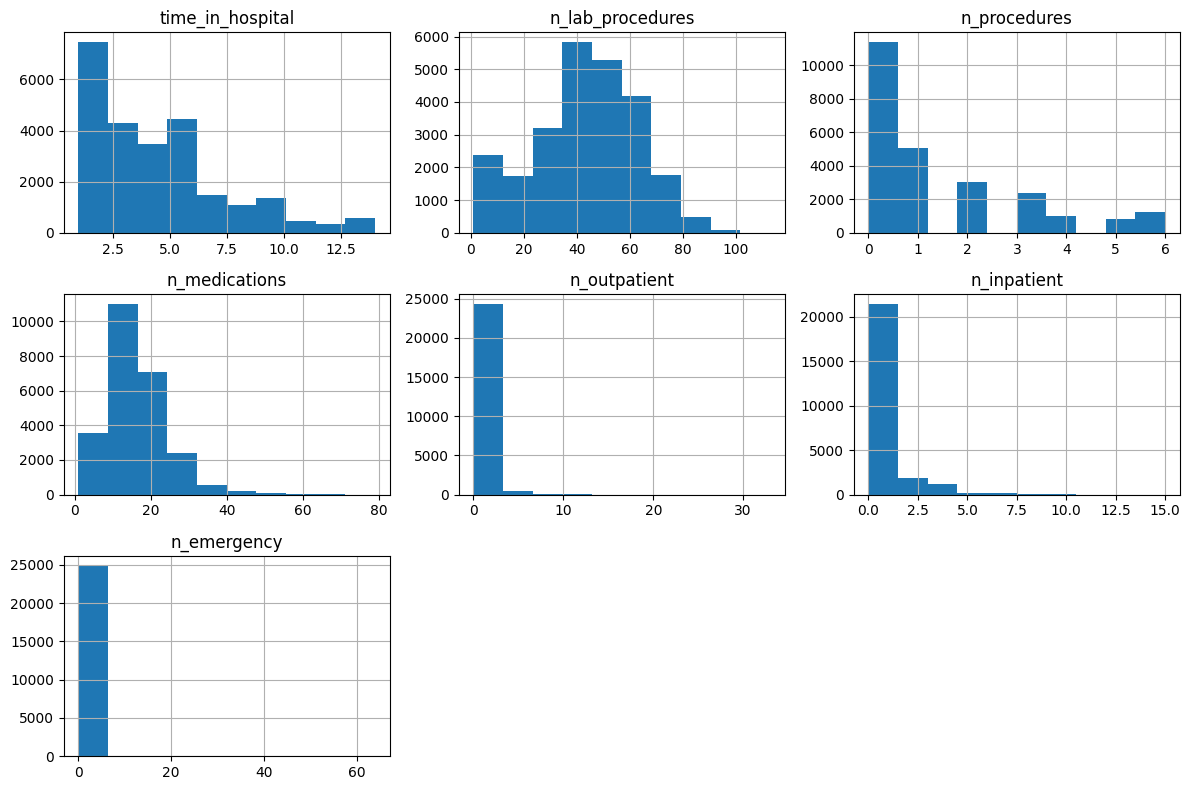

In [14]:
# Numerical Analysis

numerical_cols = [
    'time_in_hospital',
    'n_lab_procedures',
    'n_procedures',
    'n_medications',
    'n_outpatient',
    'n_inpatient',
    'n_emergency'
]

df[numerical_cols].hist(
    figsize=(12,8)
)

plt.tight_layout()
plt.show()



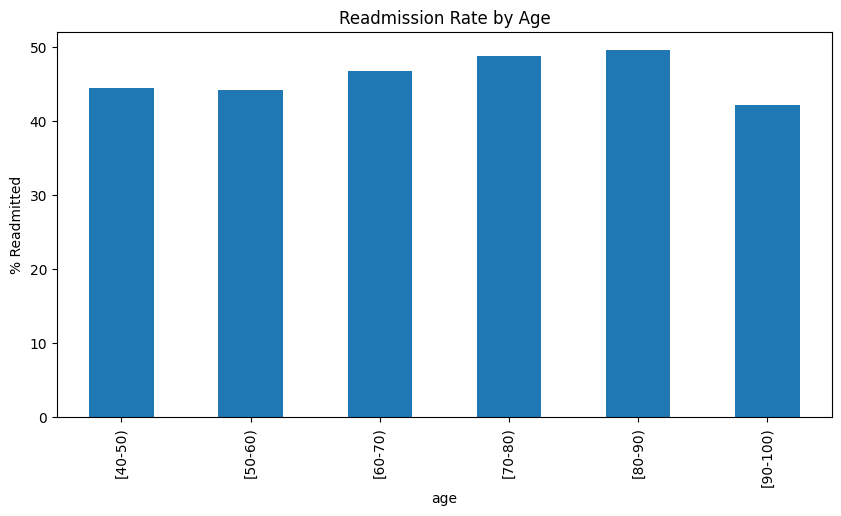

In [15]:
# Readmission rate by age

age_rate = (
    df.groupby('age')['readmitted']
      .apply(lambda x: (x=='yes').mean()*100)
)

age_rate.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Readmission Rate by Age')
plt.ylabel('% Readmitted')
plt.show()

In [16]:
# Encode Categorical Variables

categorical_cols = df.select_dtypes(
    include='object'
).columns

categorical_cols

Index(['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
       'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

In [17]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [18]:
# Create Features and Target

X = df.drop('readmitted', axis=1)

y = df['readmitted']

In [20]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
# Logistic Regression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

pred_lr = lr.predict(
    X_test
)

In [22]:
 # accuracy
 accuracy_score(
    y_test,
    pred_lr
)

0.6092

In [23]:
# classification

print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.60      0.79      0.68      2658
           1       0.63      0.41      0.49      2342

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.59      5000
weighted avg       0.61      0.61      0.59      5000



In [24]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

pred_rf = rf.predict(
    X_test
)

In [25]:
# Accuracy
accuracy_score(
    y_test,
    pred_rf
)

0.605

In [26]:
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    pred_rf
)

print(cm)

[[1820  838]
 [1137 1205]]


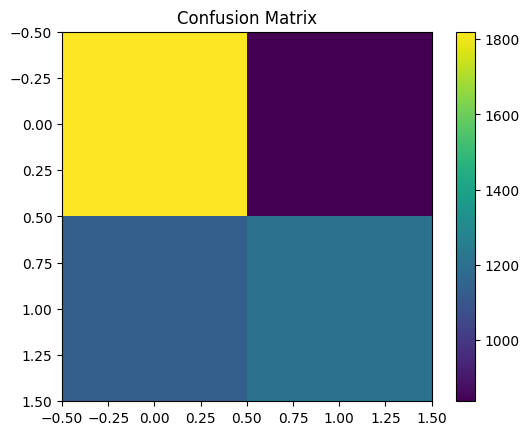

In [27]:
# Visualization
plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.colorbar()

plt.show()

In [28]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
2,n_lab_procedures,0.175649
4,n_medications,0.146184
1,time_in_hospital,0.099261
0,age,0.071579
8,medical_specialty,0.069295
9,diag_1,0.068852
11,diag_3,0.065657
10,diag_2,0.064292
3,n_procedures,0.061867
6,n_inpatient,0.054519


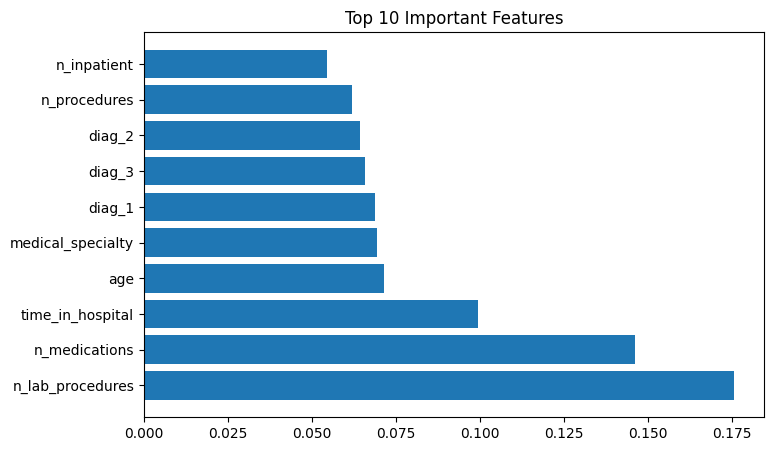

In [29]:
# Plot

top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title(
    'Top 10 Important Features'
)

plt.show()

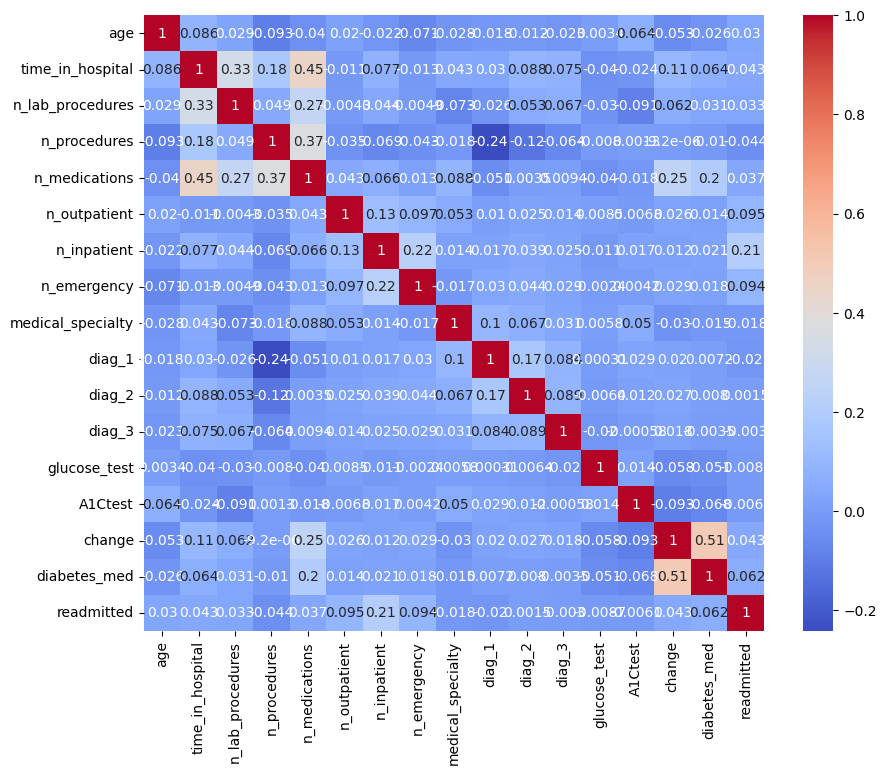

In [31]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [32]:
# Handle Class Imbalance
df['readmitted'].value_counts(normalize=True)

,proportion
readmitted,
0,0.52984
1,0.47016


In [33]:
from sklearn.utils import resample

In [34]:
from imblearn.over_sampling import SMOTE

In [36]:
!pip install xgboost

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [38]:
from xgboost import XGBClassifier

In [39]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

In [40]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)

    results.append([name, accuracy])

results_df = pd.DataFrame(
    results,
    columns=['Model','Accuracy']
)

results_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
3,Gradient Boosting,0.6192
0,Logistic Regression,0.6092
2,Random Forest,0.6050
1,Decision Tree,0.5480


In [41]:
df['readmitted'].unique()

array([0, 1])

In [42]:
df['readmitted'] = df['readmitted'].map({
    'no': 0,
    'yes': 1
})

In [43]:
best_model = results_df.sort_values('Accuracy', ascending=False).iloc[0]
best_model

,3
Model,Gradient Boosting
Accuracy,0.6192


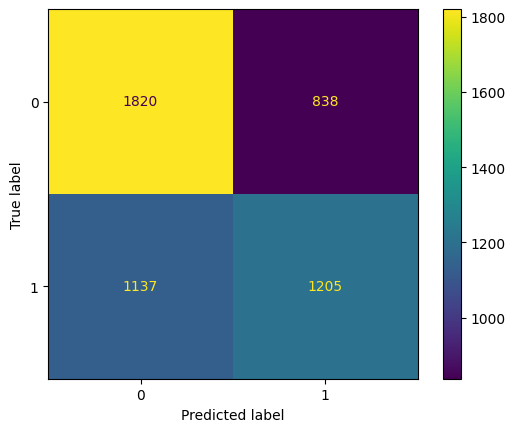

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.show()

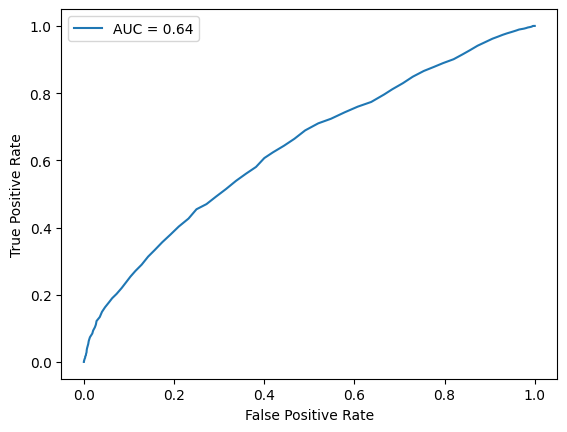

In [45]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The model shows that inpatient visits and medication count are the strongest predictors of readmission. This means patients who visit the hospital frequently or take more medications are more likely to be readmitted.

Patients with more inpatient visits have higher readmission rates -- Sick patients or unstable patients come back again

More medications = higher chance of readmission  -- Complex health conditions are harder to manage

Certain age groups have higher readmission -- Elderly patients need more care after discharge

Emergency visits = high risk group -- Patients who come to ER often are unstable

Patients with a high number of inpatient visits should be flagged for proactive follow-up.
Hospitals can schedule post-discharge calls or check-ins to reduce the risk of readmission.
Patients prescribed a higher number of medications should be closely monitored after discharge.
This group may require medication review and clearer instructions to improve treatment adherence.
High-risk age groups should receive structured discharge care plans.
This can include follow-up appointments, patient education, and early intervention support to prevent complications.